# Flow Matching Sample Transitions

Use this notebook after running `train/flow_matching.py`. It reads the local sample manifest written under `output/flow_matching_one_image/samples/` and shows generated grids in step order. The first tile in each grid is the target image; the remaining tiles are generated samples.

In [1]:
from pathlib import Path
import csv

from IPython.display import Image, display
import ipywidgets as widgets

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sample_dir = PROJECT_ROOT / "output" / "fm-03" / "samples"
manifest_path = sample_dir / "manifest.csv"
manifest_path

PosixPath('/media/plat/WDC20/Documents/python/screening/output/fm-03/samples/manifest.csv')

In [2]:
if not manifest_path.exists():
    raise FileNotFoundError(
        f"No sample manifest found at {manifest_path}. "
        "Run `uv run python train/flow_matching.py --config configs/flow_matching_one_image.yaml` first."
    )

with manifest_path.open("r", encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

grid_rows = [row for row in rows if row["kind"] == "grid"]
grid_rows = sorted(grid_rows, key=lambda row: int(row["step"]))
steps = [int(row["step"]) for row in grid_rows]
paths = [PROJECT_ROOT / row["path"] for row in grid_rows]

print(f"loaded {len(paths)} grids")
print(f"steps: {steps[:10]}{' ...' if len(steps) > 10 else ''}")

loaded 8 grids
steps: [0, 500, 1000, 1500, 2000, 2500, 3000, 3500]


In [3]:
def show_grid(index: int):
    index = int(index)
    print(f"step={steps[index]} path={paths[index].relative_to(PROJECT_ROOT)}")
    display(Image(filename=str(paths[index])))


slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(len(paths) - 1, 0),
    step=1,
    description="grid",
    continuous_update=False,
)
widgets.interact(show_grid, index=slider);

interactive(children=(IntSlider(value=0, continuous_update=False, description='grid', max=7), Output()), _dom_…

step=0


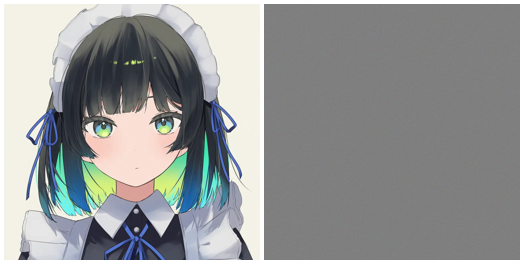

step=500


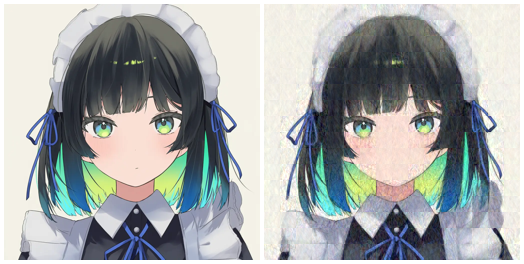

step=1000


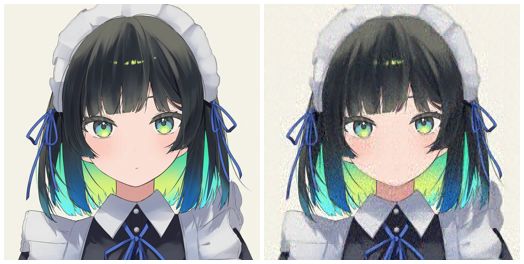

step=1500


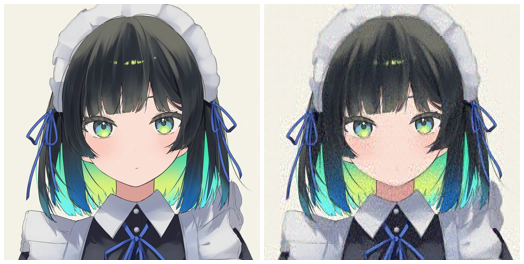

step=2000


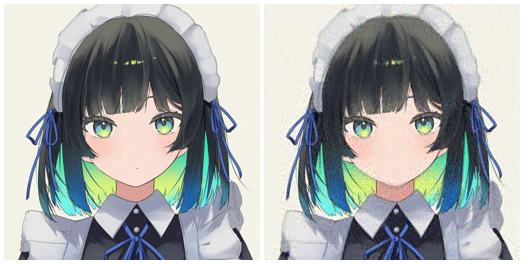

step=2500


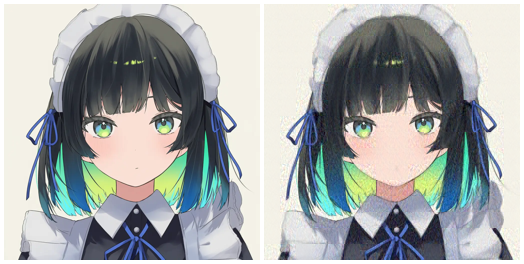

step=3000


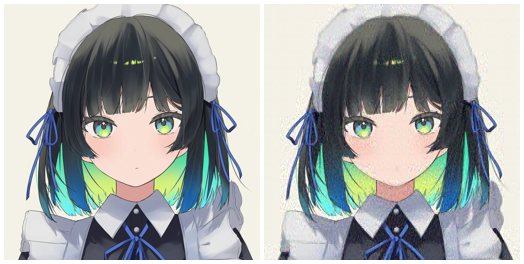

step=3500


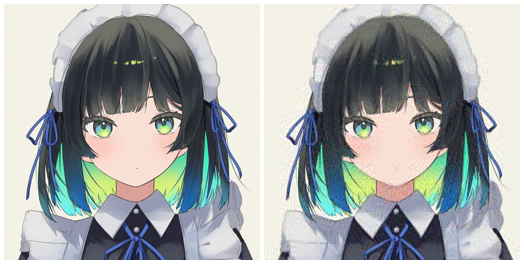

In [4]:
for step, path in zip(steps, paths):
    print(f"step={step}")
    display(Image(filename=str(path)))